All imports successful!

Test DataFrame:
      Sponsor         Driver  Avg_Finish
0       FedEx   Denny Hamlin         8.5
1  McDonald's  Bubba Wallace        15.2
2        NAPA  Chase Elliott        10.1


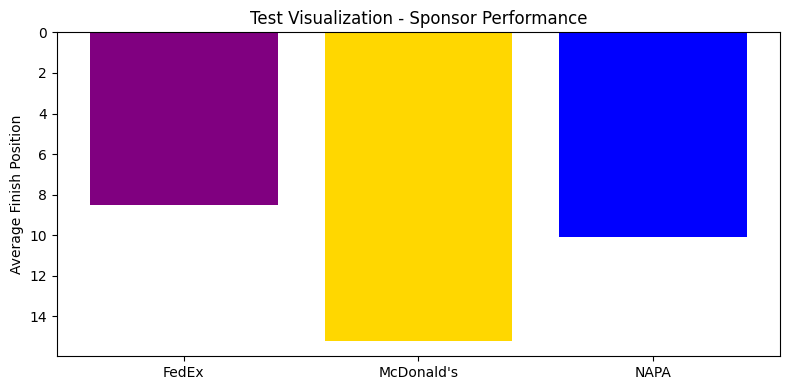


Setup complete! Chart saved to output/figures/test_chart.png


In [1]:
# Test imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import requests
import praw
from googleapiclient.discovery import build

print("All imports successful!")

# Create a simple test DataFrame
test_data = {
    'Sponsor': ['FedEx', 'McDonald\'s', 'NAPA'],
    'Driver': ['Denny Hamlin', 'Bubba Wallace', 'Chase Elliott'],
    'Avg_Finish': [8.5, 15.2, 10.1]
}
df = pd.DataFrame(test_data)
print("\nTest DataFrame:")
print(df)

# Create a simple plot
plt.figure(figsize=(8, 4))
plt.bar(df['Sponsor'], df['Avg_Finish'], color=['purple', 'gold', 'blue'])
plt.ylabel('Average Finish Position')
plt.title('Test Visualization - Sponsor Performance')
plt.gca().invert_yaxis()  # Lower is better in racing
plt.tight_layout()
plt.savefig('../output/figures/test_chart.png', dpi=150)
plt.show()

print("\nSetup complete! Chart saved to output/figures/test_chart.png")

In [2]:
import requests
import time

# Configure headers - Reddit requires a User-Agent
HEADERS = {
    'User-Agent': 'NASCAR-Visibility-Analysis/1.0 (Educational Project)'
}

# Test: Get r/NASCAR subreddit info
url = "https://www.reddit.com/r/NASCAR/about.json"
response = requests.get(url, headers=HEADERS)

if response.status_code == 200:
    data = response.json()['data']
    print("Reddit JSON API connected successfully!")
    print(f"Subreddit: r/{data['display_name']}")
    print(f"Subscribers: {data['subscribers']:,}")
    print(f"Description: {data['public_description'][:200]}...")
else:
    print(f"Error: Status code {response.status_code}")

Reddit JSON API connected successfully!
Subreddit: r/NASCAR
Subscribers: 1,486,591
Description: A subreddit for everything NASCAR related!...


In [13]:
import sys
from pathlib import Path
from googleapiclient.discovery import build

# Add project root to path so config.py can be imported
project_root = str(Path().resolve().parent)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from config import YOUTUBE_API_KEY

youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)

# Test: Search for NASCAR race highlights
request = youtube.search().list(
    q="NASCAR Cup Series 2024 highlights",
    part="snippet",
    maxResults=3,
    type="video"
)
response = request.execute()

print("YouTube API Test - NASCAR Search Results:")
print("-" * 50)
for item in response['items']:
    print(f"Title: {item['snippet']['title']}")
    print(f"Channel: {item['snippet']['channelTitle']}")
    print(f"Published: {item['snippet']['publishedAt'][:10]}")
    print("-" * 50)


YouTube API Test - NASCAR Search Results:
--------------------------------------------------
Title: 2024 Daytona 500 Highlights | NASCAR on FOX
Channel: NASCAR on FOX
Published: 2024-02-20
--------------------------------------------------
Title: NASCAR Cup Series EXTENDED HIGHLIGHTS: Championship race at Phoenix | 11/10/24 | Motorsports on NBC
Channel: Motorsports on NBC
Published: 2024-11-11
--------------------------------------------------
Title: 2024 NASCAR Cup Series season in three minutes | NASCAR
Channel: NASCAR
Published: 2024-11-11
--------------------------------------------------
